In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

In [39]:
df = pd.read_csv("data/raw/Media-Matrix-Combined-v4-moles-per-litre-annotate.csv")
print(df.shape)

(62, 28)


In [40]:
# run this to remove these compounds from analysis
# filter rows that were considered not important


compounds_to_remove = [
    'Dipotassium phosphate', 'Disodium edta dihydrate', 'EDTA', 'Monopotassium phosphate',
    'Phosphoric acid', 'Potassium hydroxide', 'Sodium citrate dihydrate', 'Sodium phosphate',
    'Sulphuric acid', 'Uracil'
]
df = df[~df['Compound'].isin(compounds_to_remove)].copy()

print(df.shape)

(52, 28)


In [41]:
# remove pubchemid
df.drop(df.columns[1], axis=1, inplace=True)

In [42]:
# separate numeric columns for transformation
num_df = df.select_dtypes(include='number')

In [43]:
labels = df[['Compound', 'Annotate']]

In [44]:
pseudocount = 1e-10
num_df=np.log10(num_df.replace(0, pseudocount))


In [45]:
df_log = pd.concat([labels, num_df], axis=1)

In [46]:
yar_df = df_log.filter(like='_YAR')
cer_df = df_log.filter(like='_CER')
pic_df = df_log.filter(like='_PIC')

In [47]:
print(df_log.shape)
print(yar_df.shape)
print(cer_df.shape)     
print(pic_df.shape)

(52, 27)
(52, 10)
(52, 6)
(52, 9)


In [48]:
# labels are missing for individual dfs

yar_df.head()

,1_YAR,2a_YAR,2b_YAR,2c_YAR,2d_YAR,3a_YAR,3b_YAR,3c_YAR,4_YAR,5_YAR
0,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
1,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
2,-1.544693,-1.422064,-1.422064,-1.422064,-1.422064,-10.0,-1.518974,-1.467822,-1.422064,-1.217944
3,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000
4,-10.000000,-10.000000,-10.000000,-10.000000,-10.000000,-10.0,-10.000000,-10.000000,-10.000000,-10.000000


In [49]:
df_long = pd.melt(df_log, id_vars=['Compound', 'Annotate'], var_name='Sample', value_name='Log10_Concentration')

In [50]:
# Add an 'Organism' column based on the suffix in 'Sample'
df_long['Organism'] = df_long['Sample'].str.extract(r'_([A-Z]+)$')


In [51]:
df_long['Annotate_Compound'] = df_long['Annotate'] + ' - ' + df_long['Compound']

ordered_x = sorted(df_long['Annotate_Compound'].unique()
                   )

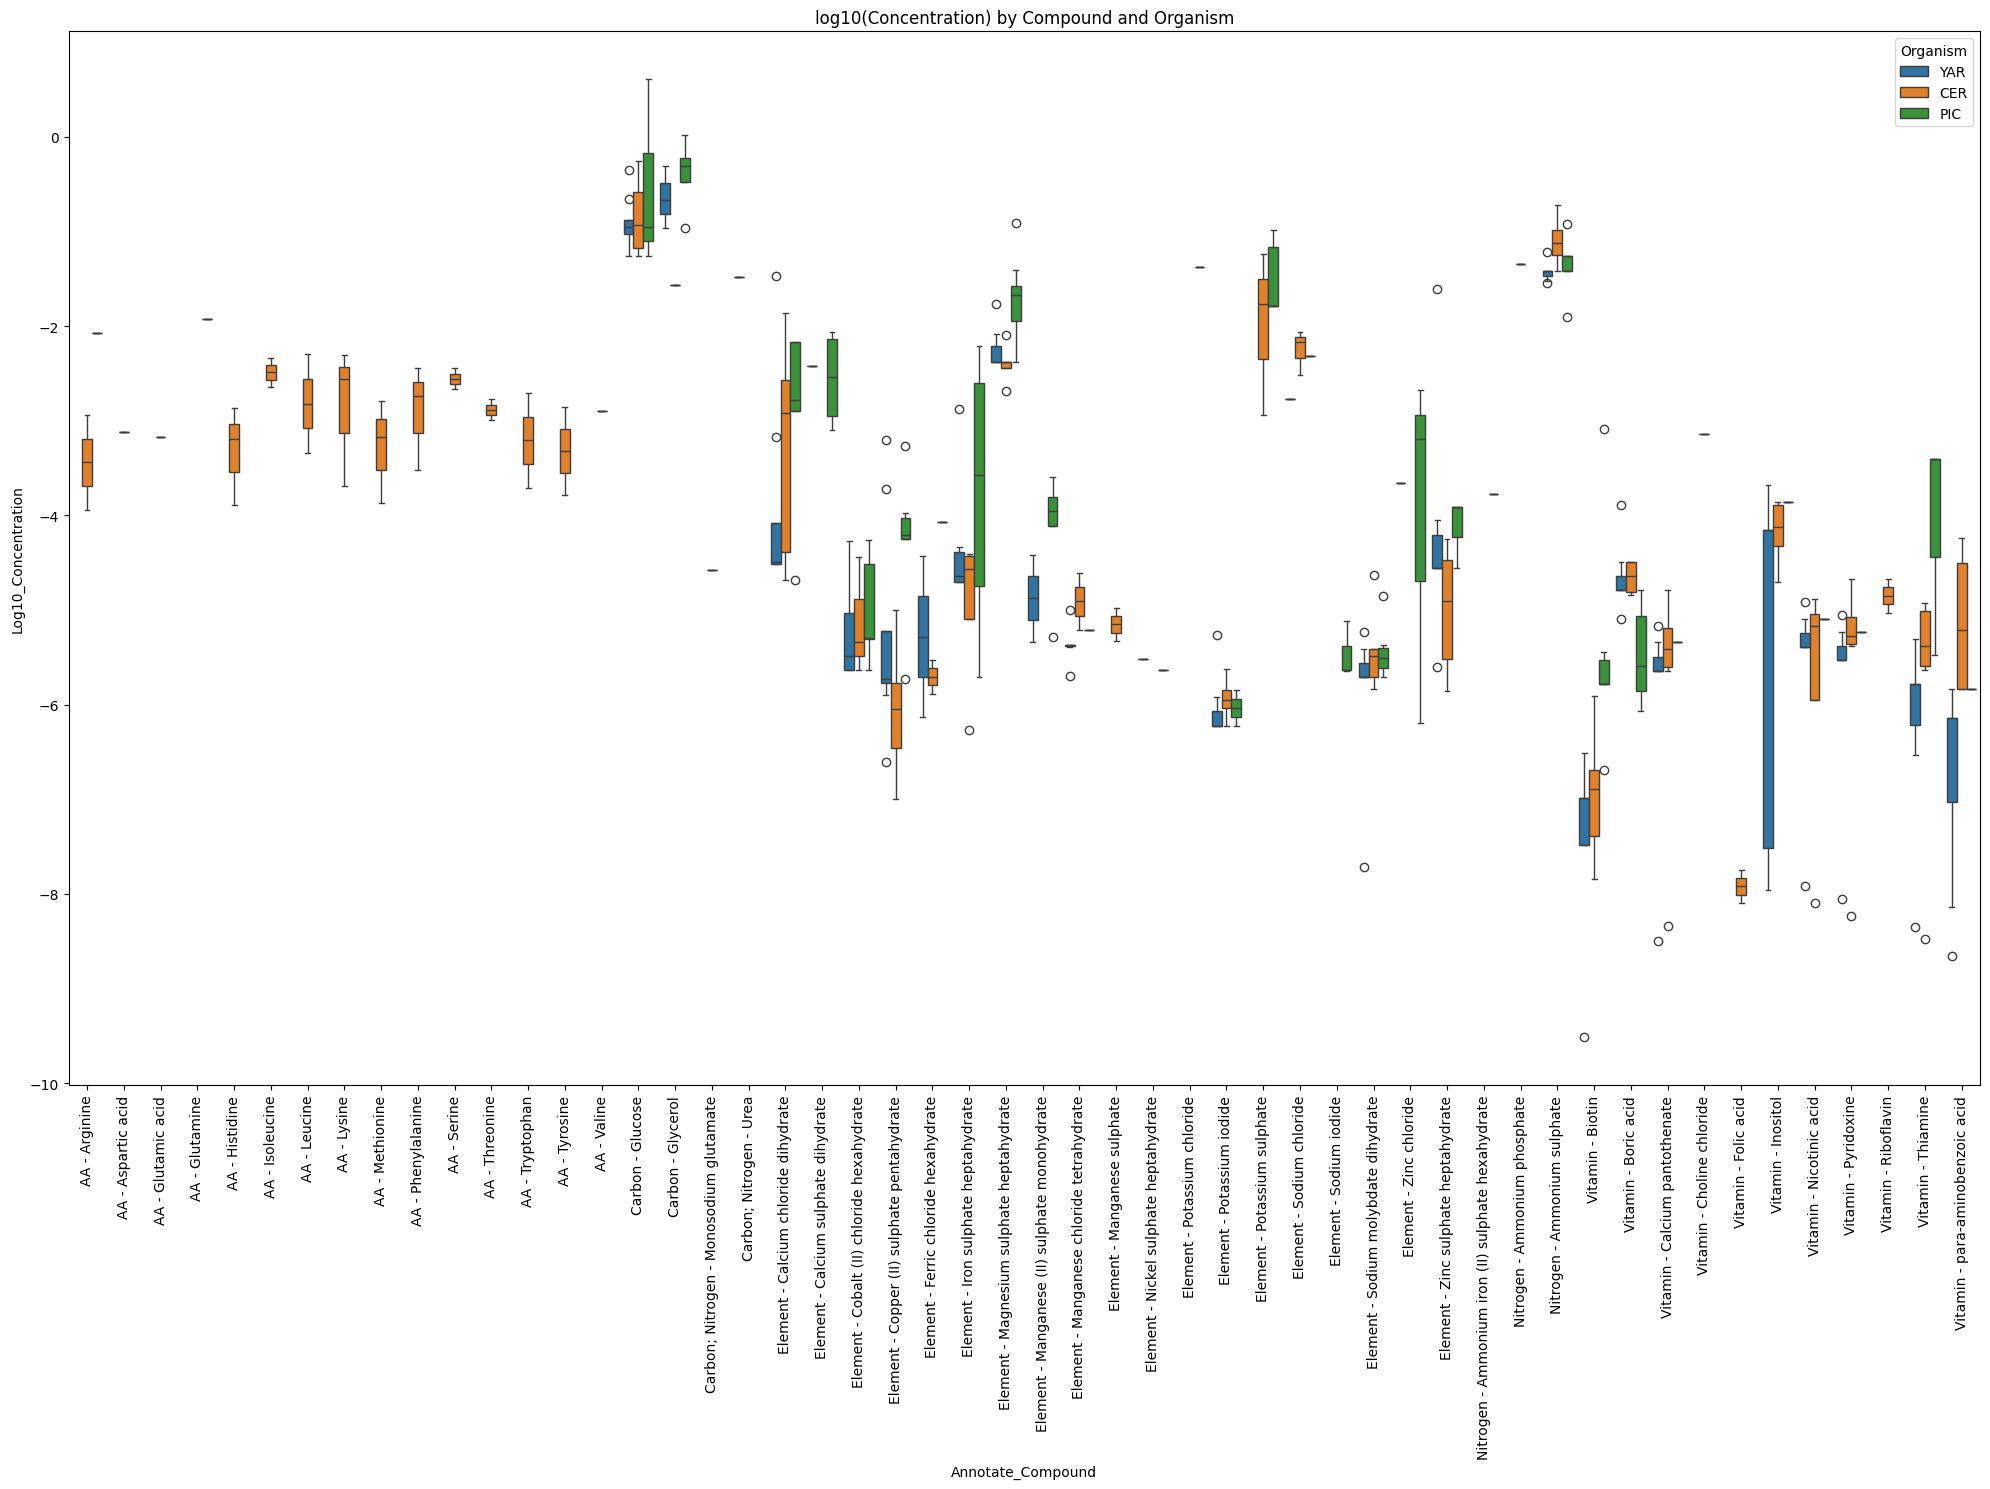

In [52]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df_long[df_long['Log10_Concentration'] > -10],  # exclude pseudocount
            x='Annotate_Compound', y='Log10_Concentration', hue='Organism', order=ordered_x)
plt.xticks(rotation=90)
plt.title('log10(Concentration) by Compound and Organism')
plt.tight_layout()
plt.show()

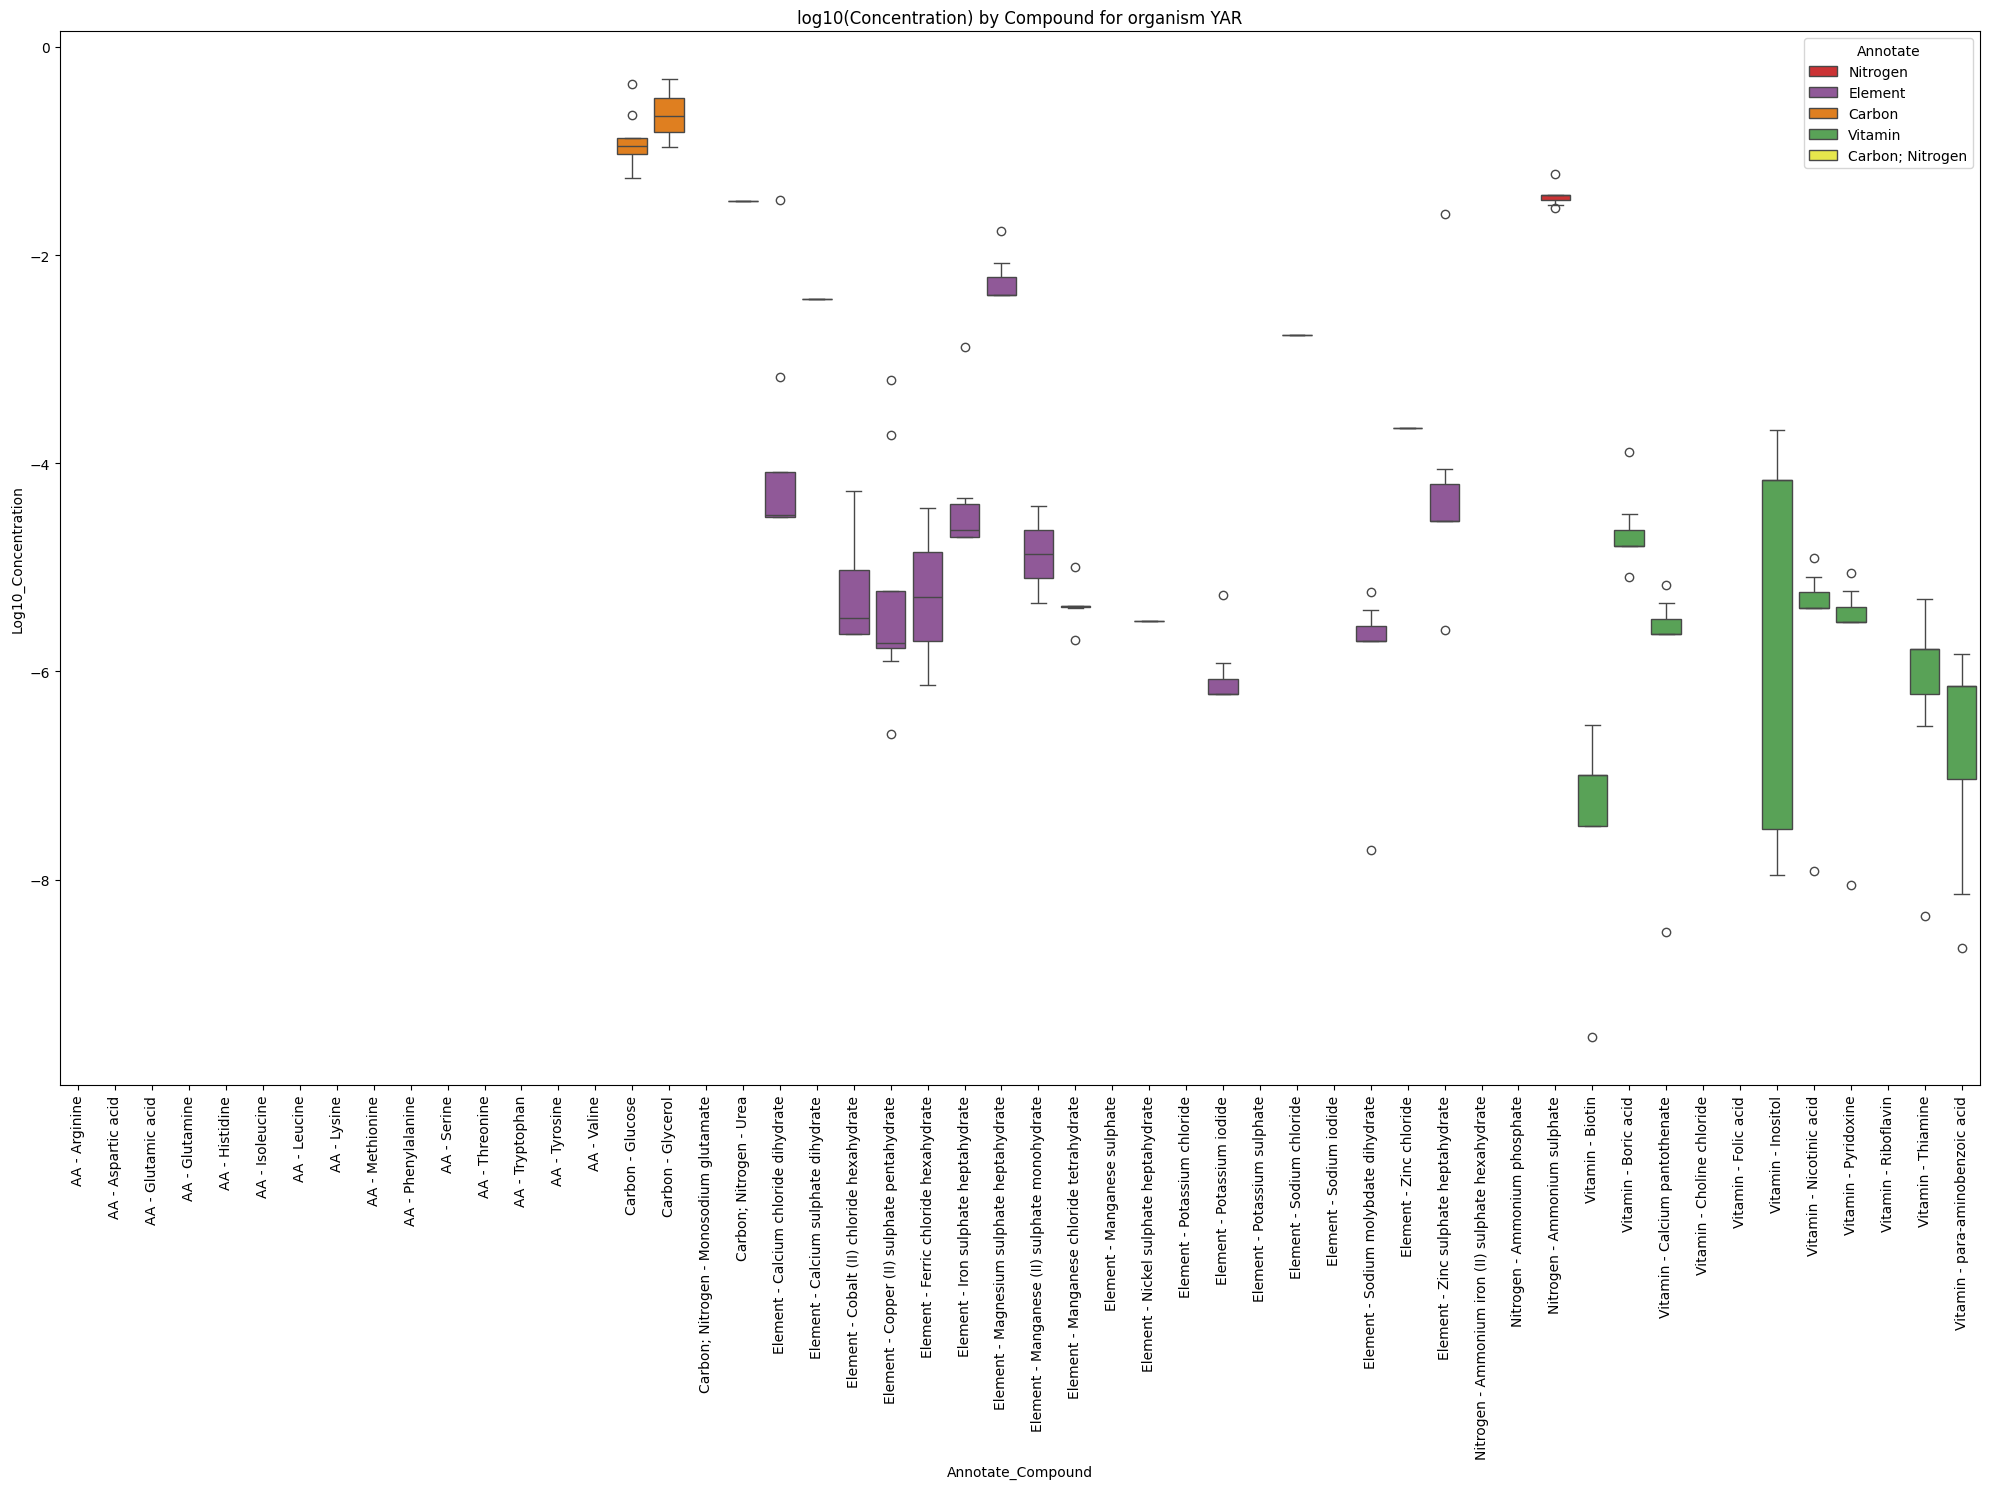

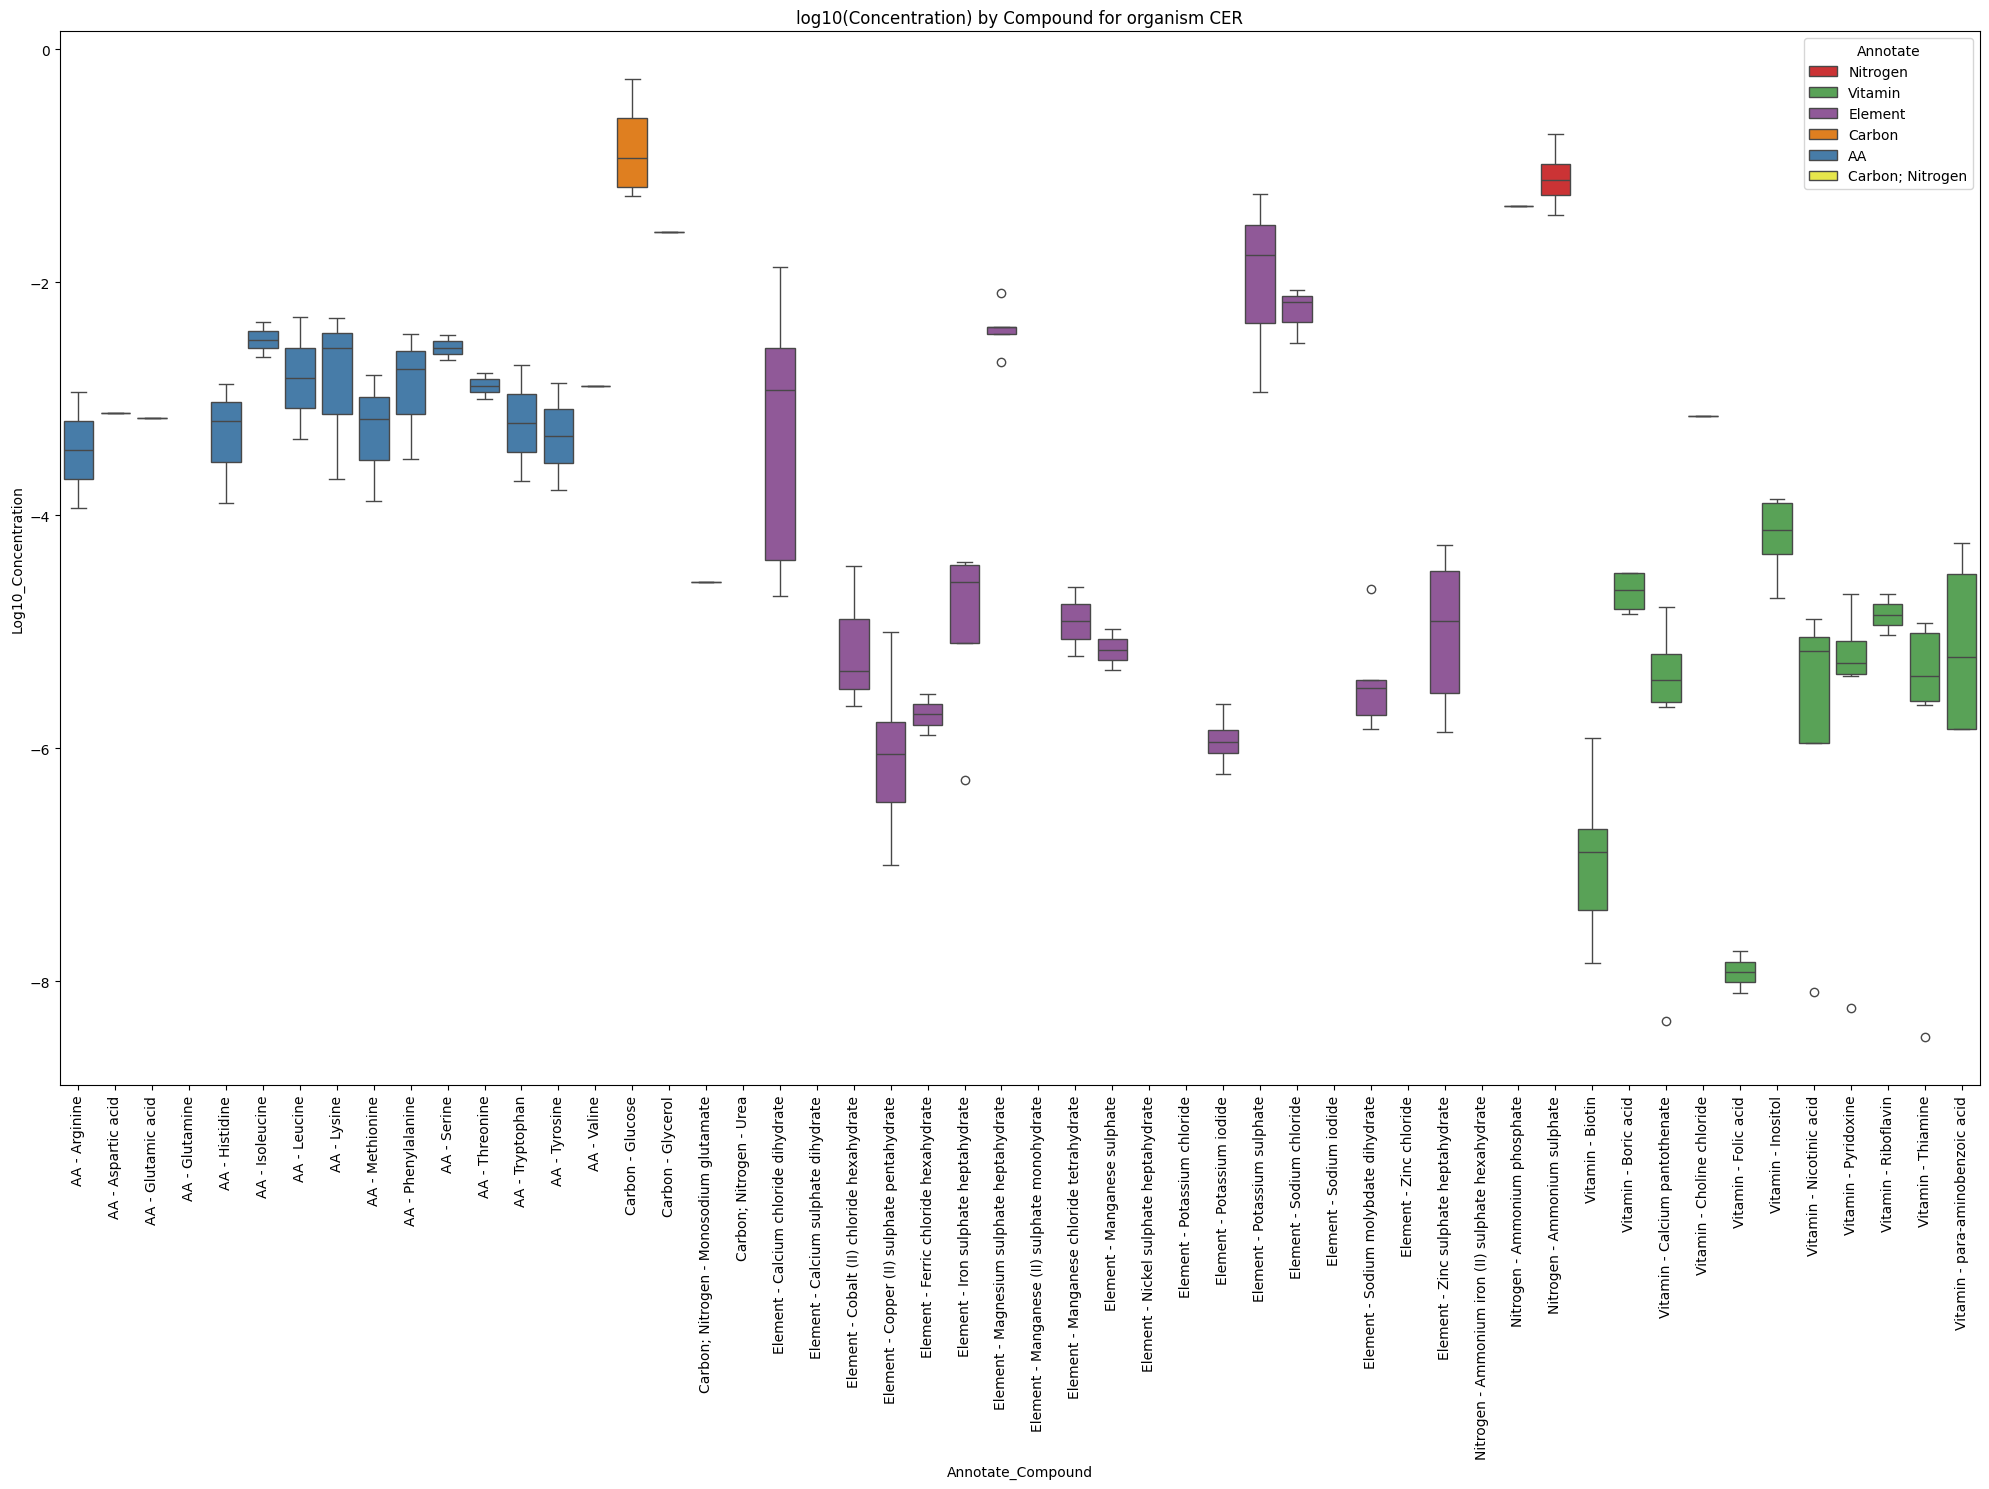

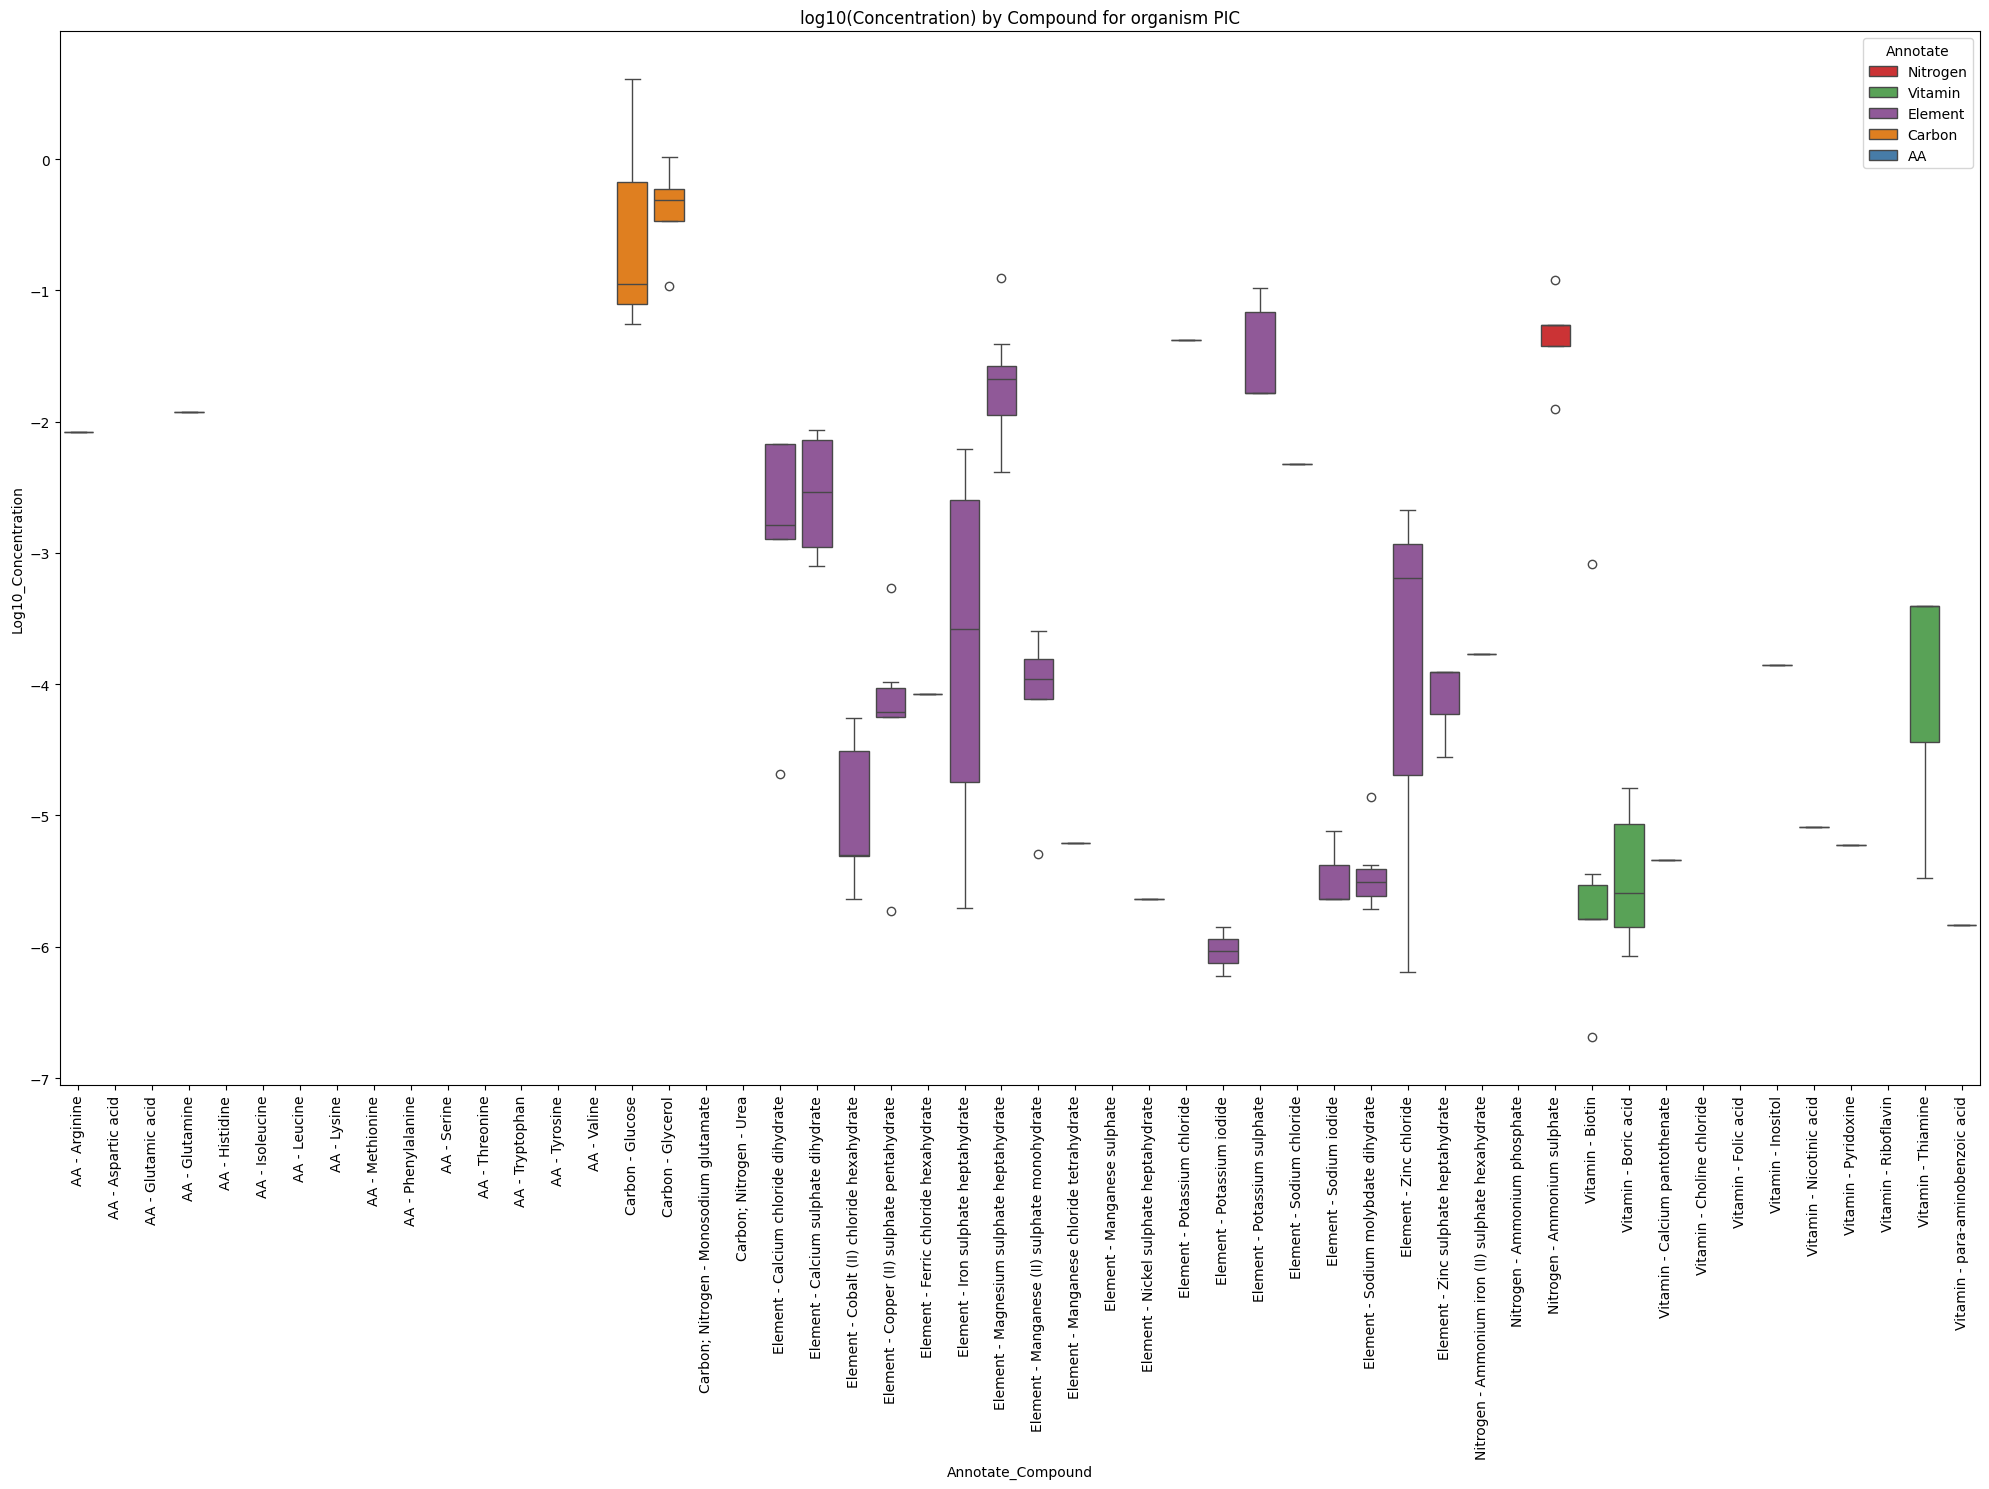

In [53]:
organisms = ['YAR', 'CER', 'PIC']


# Define all possible categories and assign fixed colors
unique_annotates = df_long['Annotate'].dropna().unique()
palette = dict(zip(unique_annotates, sns.color_palette("Set1", len(unique_annotates))))

for org in organisms:
    plt.figure(figsize=(20, 15))
    subset = df_long[(df_long['Organism'] == org) & (df_long['Log10_Concentration'] > -10)]
    sns.boxplot(data=subset,
                x='Annotate_Compound', y='Log10_Concentration', hue = 'Annotate', palette=palette, order=ordered_x)
    plt.xticks(rotation=90)
    plt.title(f'log10(Concentration) by Compound for organism {org}')
    plt.tight_layout()
    plt.show()

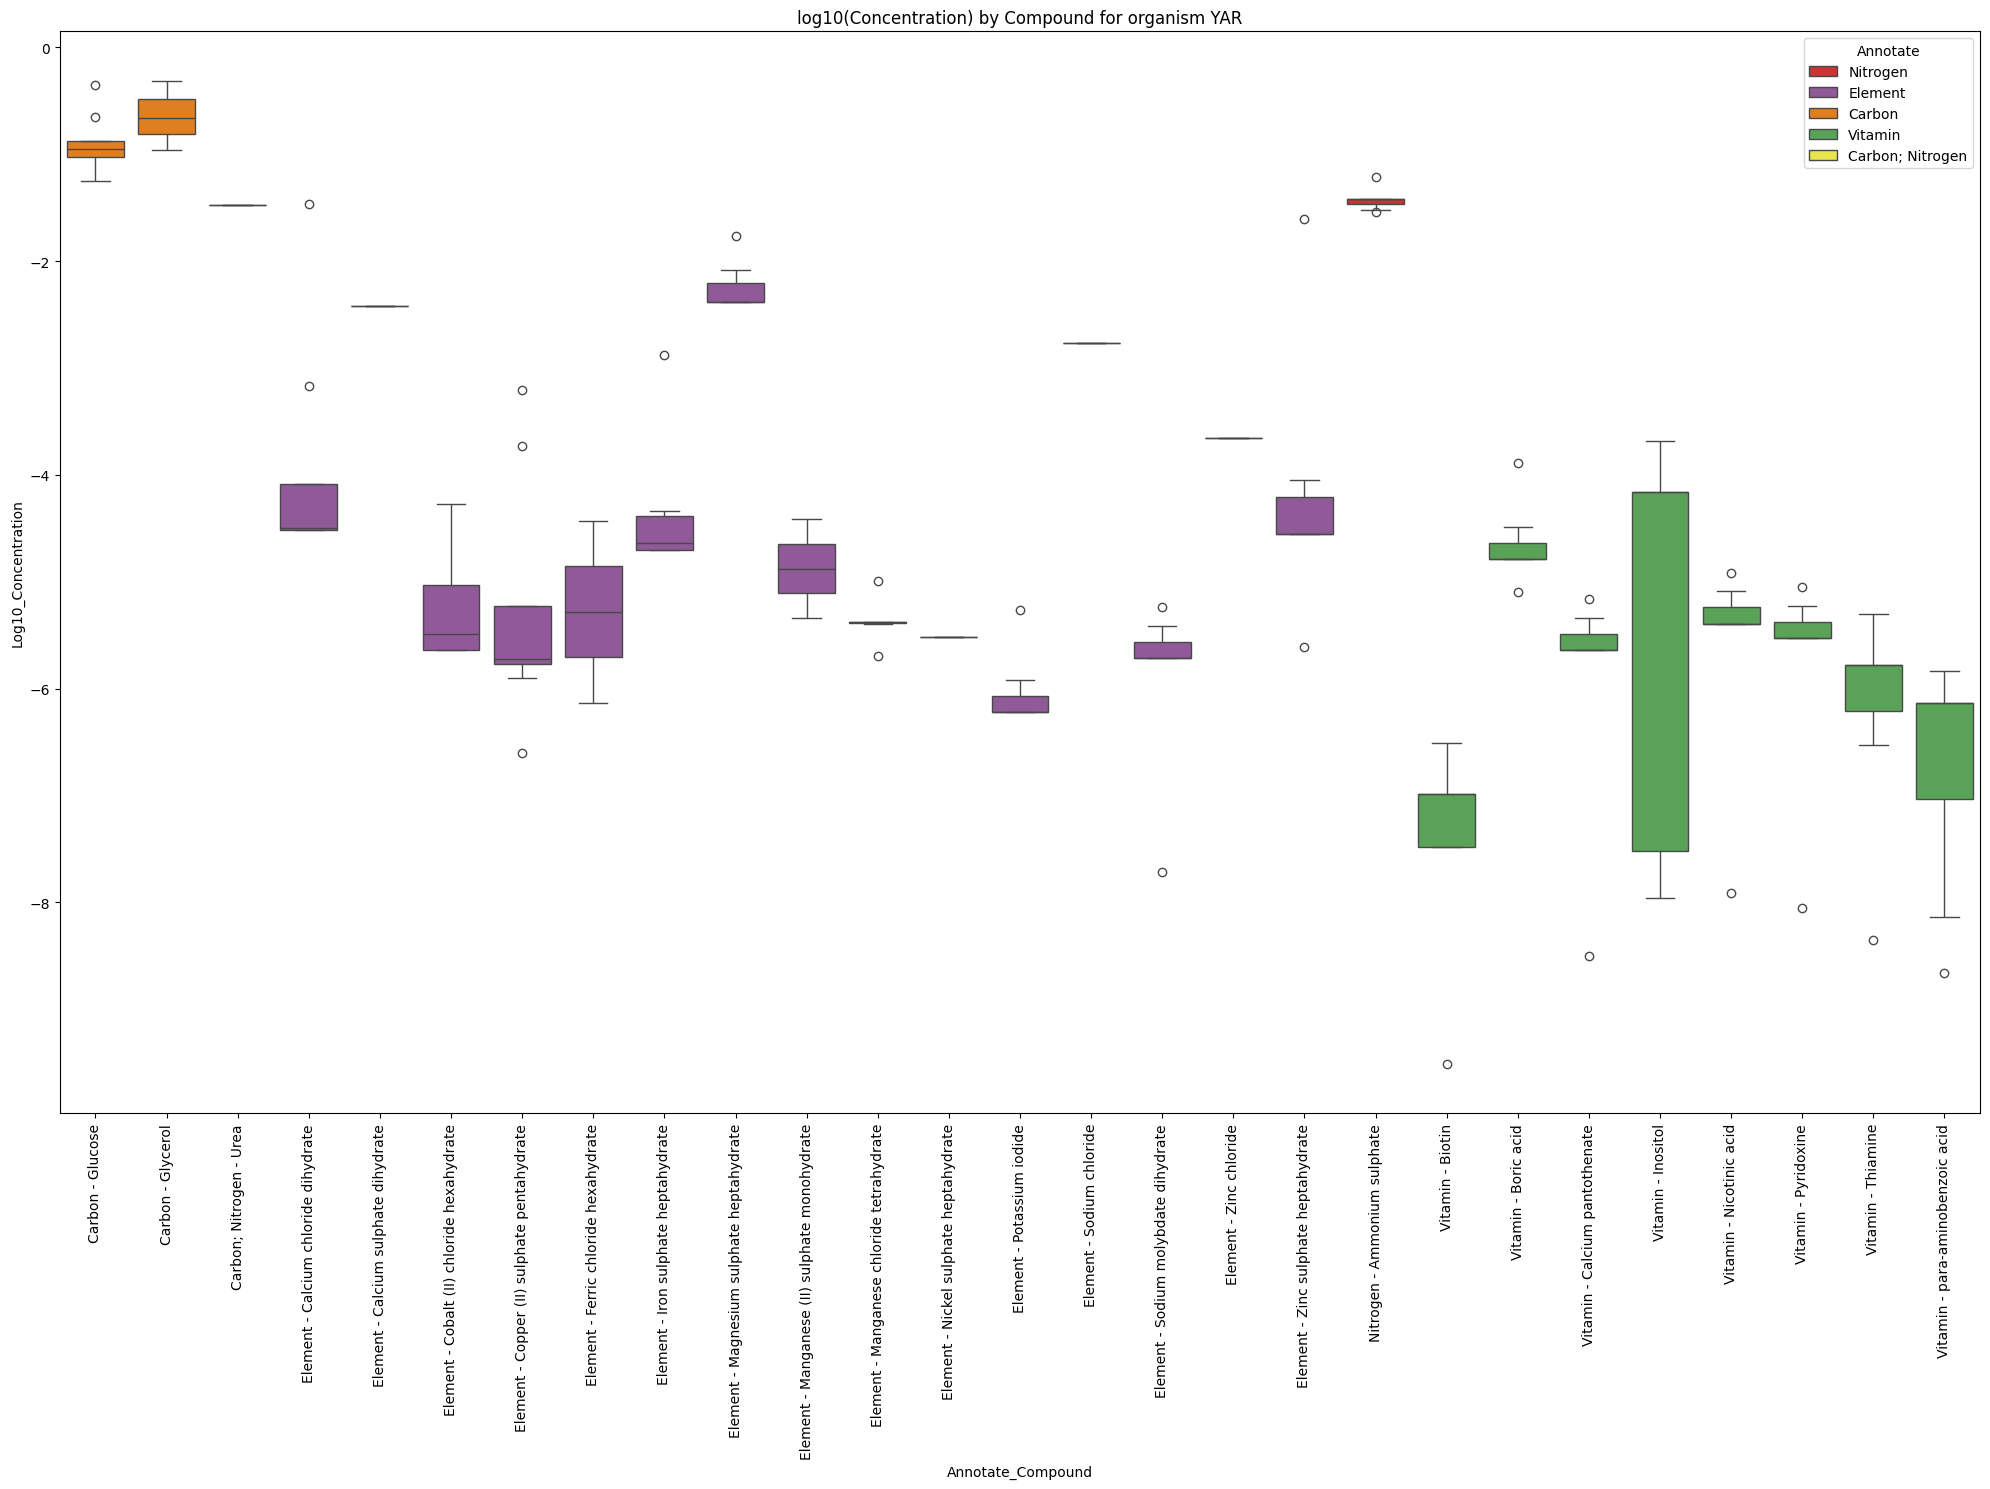

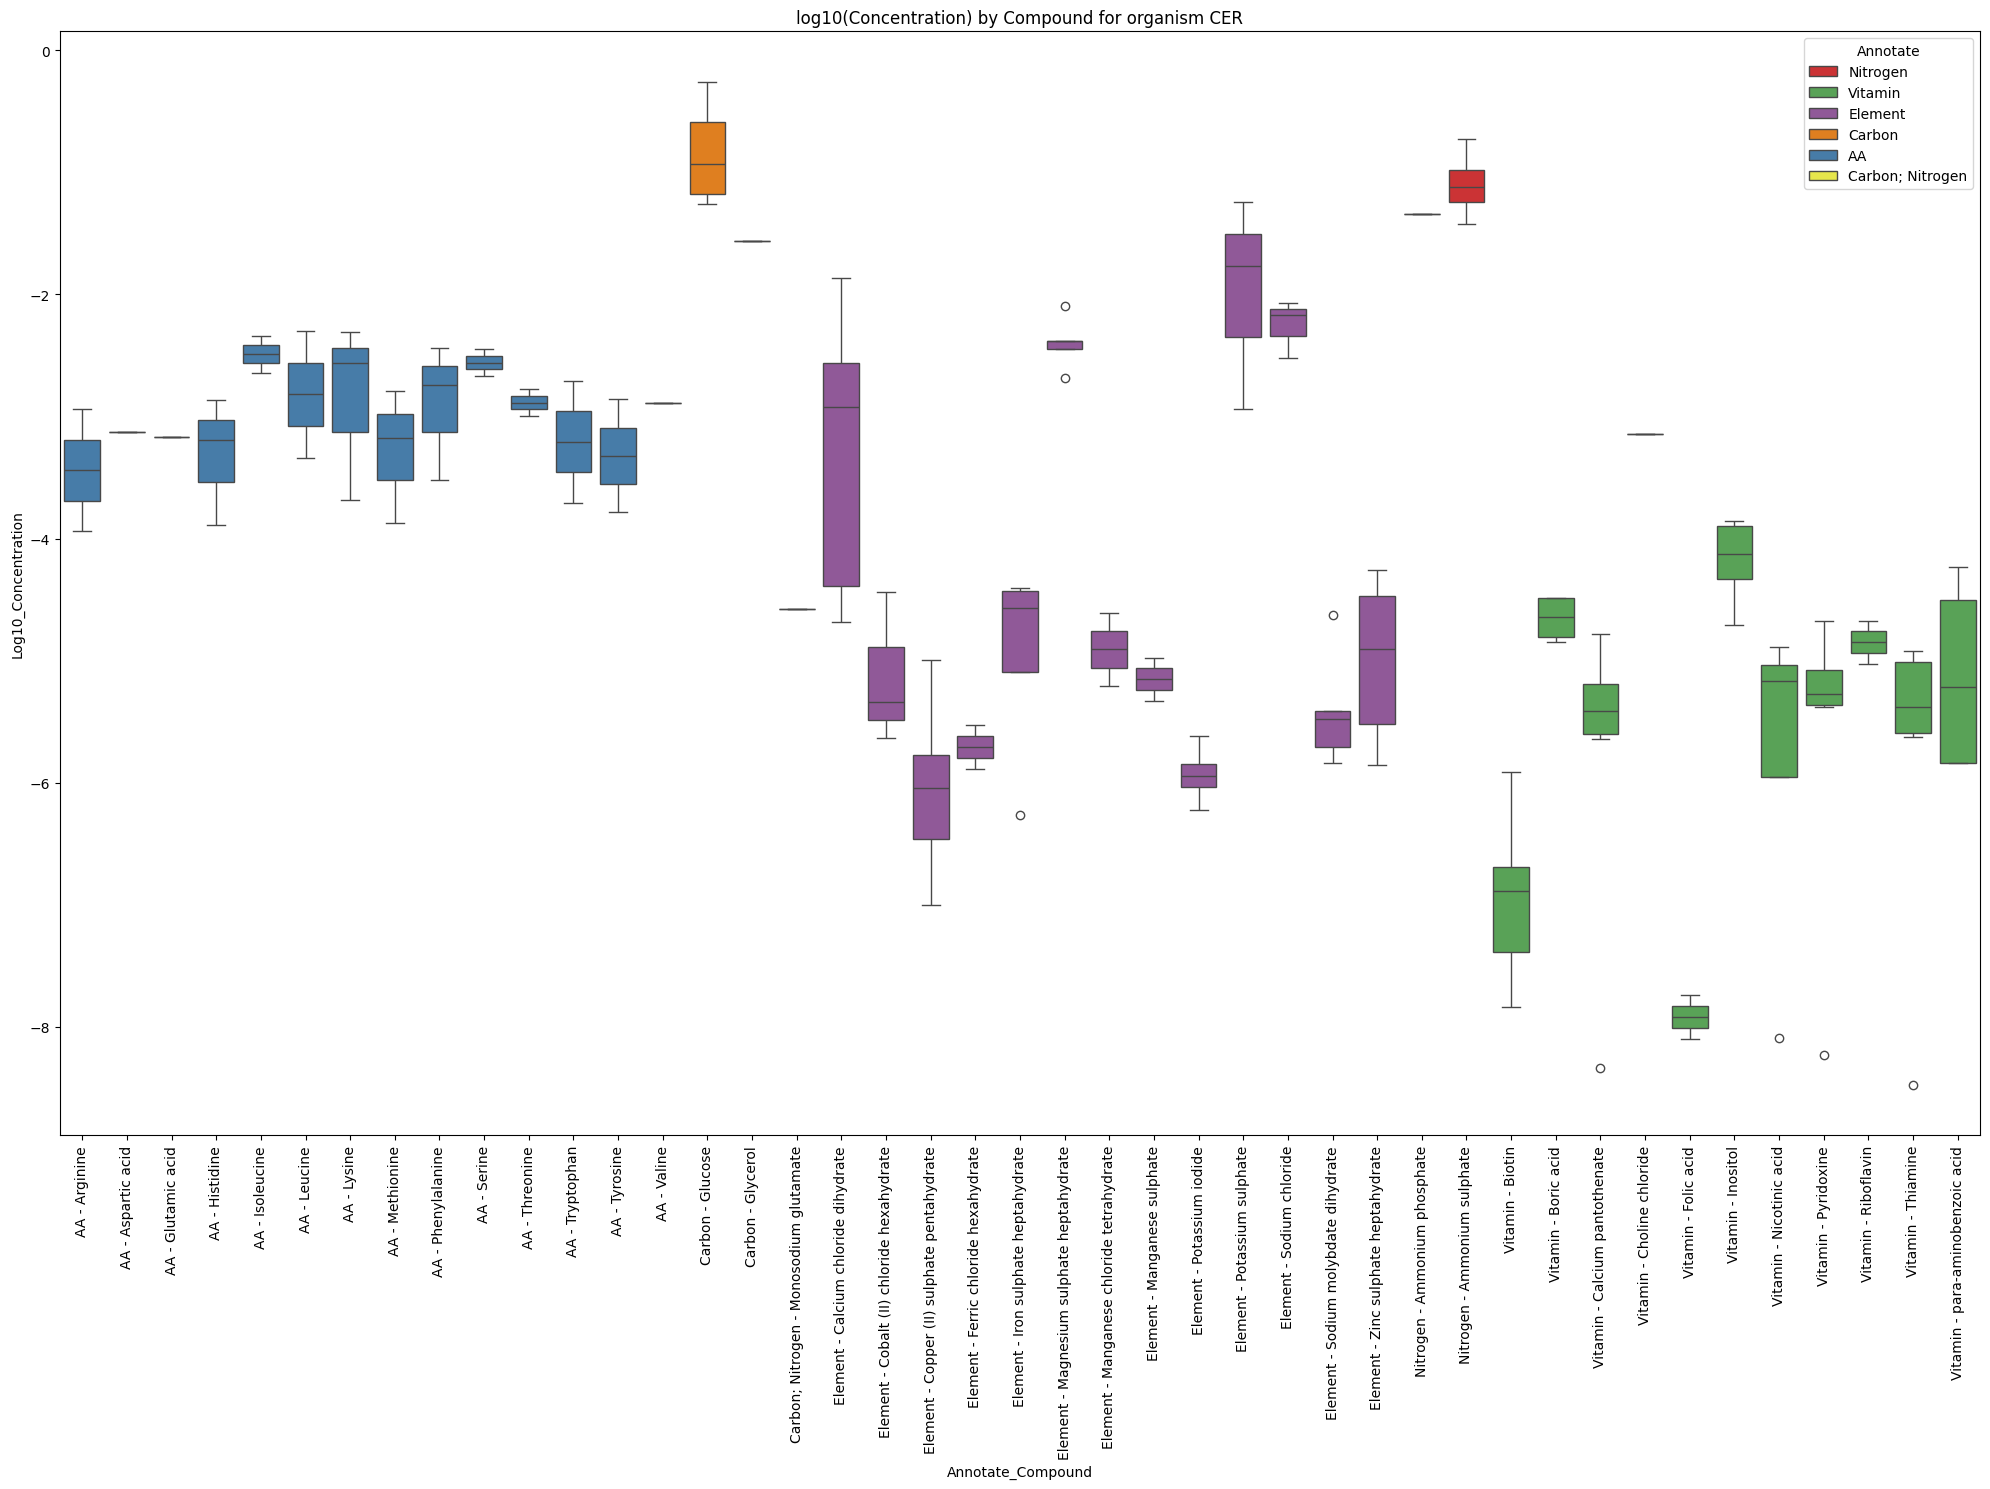

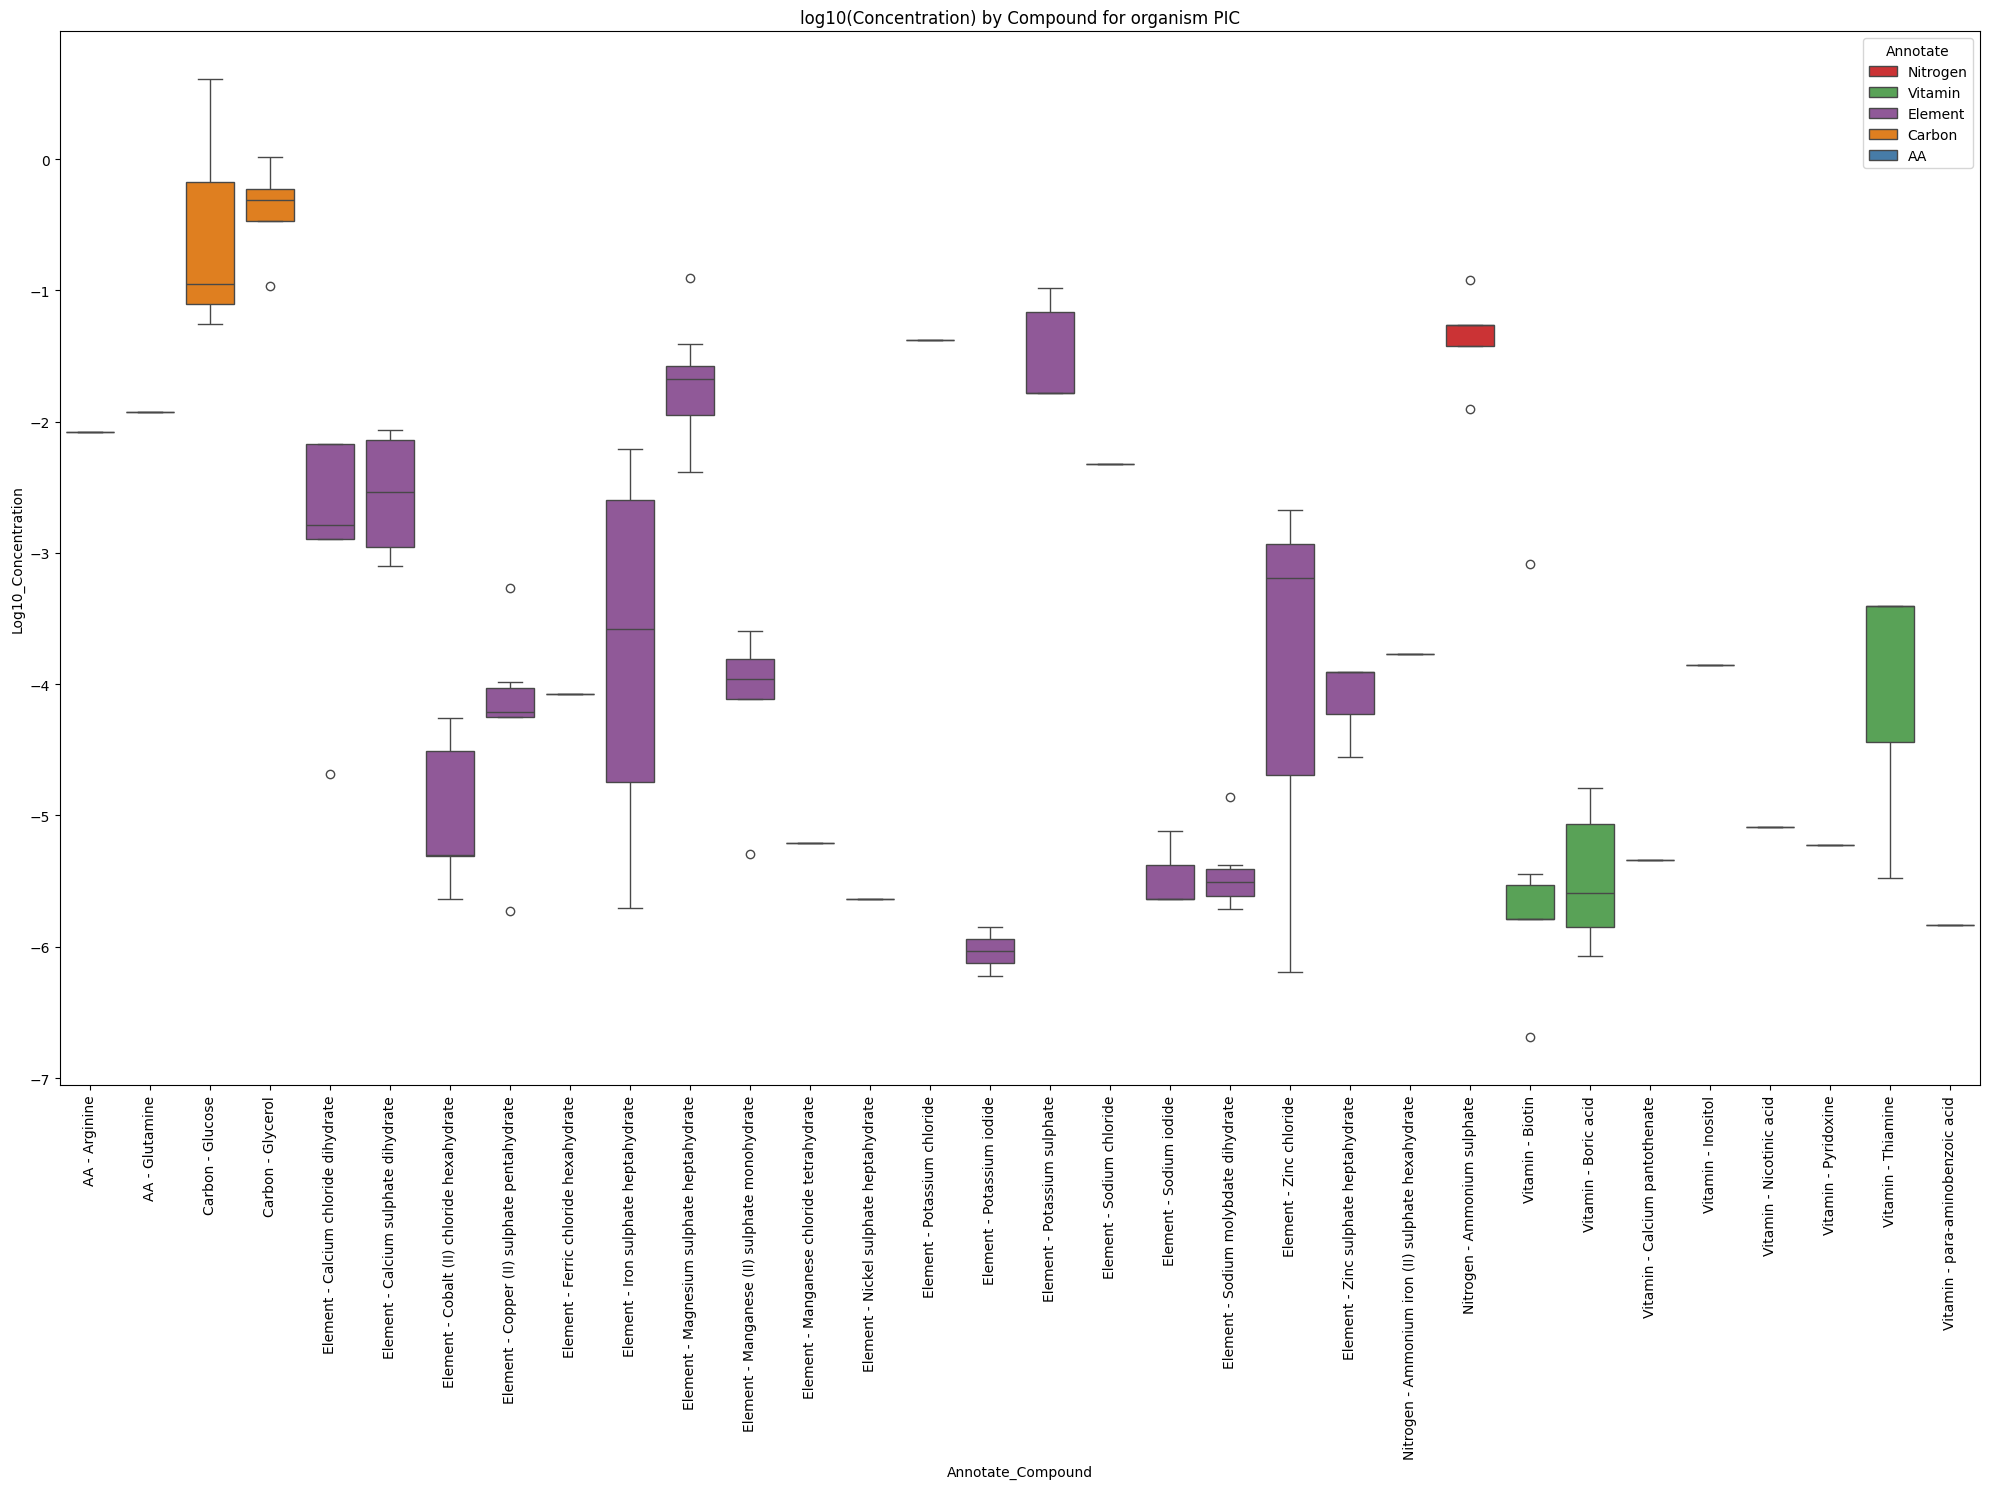

In [54]:
for org in organisms:
    plt.figure(figsize=(20, 15))
    subset = df_long[(df_long['Organism'] == org) & (df_long['Log10_Concentration'] > -10)]

    # Filter x-axis to only include compounds present in this subset
    present_compounds = subset['Annotate_Compound'].unique()
    filtered_order = [comp for comp in ordered_x if comp in present_compounds]

    sns.boxplot(data=subset,
                x='Annotate_Compound',
                y='Log10_Concentration',
                hue='Annotate',
                order=filtered_order,
                palette=palette)
    plt.xticks(rotation=90)
    plt.title(f'log10(Concentration) by Compound for organism {org}')
    plt.tight_layout()
    plt.show()


In [55]:
yar_df_labeled = pd.concat([labels, yar_df], axis=1)

In [56]:
# Define which columns are sample measurements (everything except metadata)
sample_cols = yar_df_labeled.columns.difference(['Compound', 'Annotate'])

# Filter to keep rows where at least one sample value ≠ -10
yar_df_labeled = yar_df_labeled[
    yar_df_labeled['Annotate'].isin(['Vitamin', 'Element']) &
    ~(yar_df_labeled[sample_cols] == -10).all(axis=1)
].copy()

In [57]:
# let's remove redundant elements for calcium iron, manganese, sodium chloride and zinc chloride
yar_df_labeled = yar_df_labeled.drop(index=[9, 16, 29, 35, 46, 59])

In [58]:
print(yar_df_labeled)

                             Compound Annotate      1_YAR    2a_YAR    2b_YAR  \
5                              Biotin  Vitamin -10.000000 -6.990001 -6.990001   
6                          Boric acid  Vitamin -10.000000 -4.791269 -4.791269   
7          Calcium chloride dihydrate  Element -10.000000 -4.514134 -4.514134   
8                Calcium pantothenate  Vitamin -10.000000 -5.641930 -5.641930   
11   Cobalt (II) chloride hexahydrate  Element  -4.978509 -5.636287 -5.636287   
12  Copper (II) sulphate pentahydrate  Element  -3.725939 -5.725939 -5.725939   
23                           Inositol  Vitamin  -7.255658 -4.158748 -4.158748   
24         Iron sulphate heptahydrate  Element  -2.880556 -4.704465 -4.704465   
28    Magnesium sulphate heptahydrate  Element  -1.768764 -2.381548 -2.381548   
30    Manganese chloride tetrahydrate  Element -10.000000 -5.372167 -5.372167   
36                     Nicotinic acid  Vitamin -10.000000 -5.391323 -5.391323   
41                   Potassi

In [59]:
yar_df_element = yar_df_labeled[yar_df_labeled['Annotate'] == 'Element'].copy()
yar_df_vitamin = yar_df_labeled[yar_df_labeled['Annotate'] == 'Vitamin'].copy()


In [60]:
print(yar_df_vitamin)
print(yar_df_element)

                  Compound Annotate      1_YAR    2a_YAR    2b_YAR    2c_YAR  \
5                   Biotin  Vitamin -10.000000 -6.990001 -6.990001 -6.990001   
6               Boric acid  Vitamin -10.000000 -4.791269 -4.791269 -4.791269   
8     Calcium pantothenate  Vitamin -10.000000 -5.641930 -5.641930 -5.641930   
23                Inositol  Vitamin  -7.255658 -4.158748 -4.158748 -4.158748   
36          Nicotinic acid  Vitamin -10.000000 -5.391323 -5.391323 -5.391323   
43              Pyridoxine  Vitamin -10.000000 -5.529379 -5.529379 -5.529379   
52                Thiamine  Vitamin  -6.172941 -5.779322 -5.779322 -5.779322   
61  para-aminobenzoic acid  Vitamin  -8.137164 -6.137164 -6.137164 -6.137164   

      2d_YAR     3a_YAR     3b_YAR    3c_YAR     4_YAR      5_YAR  
5  -6.990001  -7.484851  -7.484851 -9.512880 -6.688971  -6.512880  
6  -4.791269  -5.092299 -10.000000 -3.888180 -4.490239 -10.000000  
8  -5.641930 -10.000000 -10.000000 -8.501972 -5.340900  -5.164809  
23 -4.1

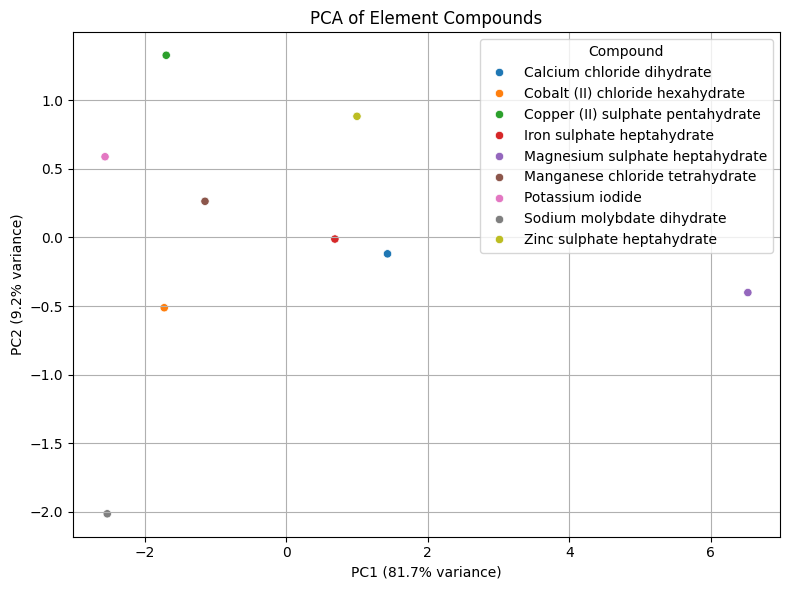

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Columns that are samples (not Compound/Annotate)
sample_cols = yar_df_element.columns.difference(['Compound', 'Annotate'])

# Extract sample values and normalize
X = yar_df_element[sample_cols].replace(-10, np.nan)
X_imputed = SimpleImputer(strategy='mean').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Compound'] = yar_df_element['Compound'].values
pca_df['Annotate'] = yar_df_element['Annotate'].values

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Compound', palette='tab10', legend='full')
plt.title('PCA of Element Compounds')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
print(yar_df_element)

                             Compound Annotate      1_YAR    2a_YAR    2b_YAR  \
7          Calcium chloride dihydrate  Element -10.000000 -4.514134 -4.514134   
11   Cobalt (II) chloride hexahydrate  Element  -4.978509 -5.636287 -5.636287   
12  Copper (II) sulphate pentahydrate  Element  -3.725939 -5.725939 -5.725939   
24         Iron sulphate heptahydrate  Element  -2.880556 -4.704465 -4.704465   
28    Magnesium sulphate heptahydrate  Element  -1.768764 -2.381548 -2.381548   
30    Manganese chloride tetrahydrate  Element -10.000000 -5.372167 -5.372167   
41                   Potassium iodide  Element -10.000000 -6.220115 -6.220115   
49         Sodium molybdate dihydrate  Element  -5.614750 -5.711660 -5.711660   
60         Zinc sulphate heptahydrate  Element -10.000000 -4.554691 -4.554691   

      2c_YAR    2d_YAR     3a_YAR     3b_YAR     3c_YAR     4_YAR      5_YAR  
7  -4.514134 -4.514134  -3.167347 -10.000000  -1.468377 -4.386340  -4.480245  
11 -5.636287 -5.636287 -10.0000

In [63]:
import itertools

# Set up
df_e = yar_df_element.copy()
sample_cols = df_e.columns.difference(['Compound', 'Annotate'])

# Initialize list for results
ratios = []

# All unique compound pairs
compound_pairs = list(itertools.combinations(df_e['Compound'], 2))

# Map for quick lookup
compound_map = df_e.set_index('Compound')[sample_cols]

# Loop through pairs
for c1, c2 in compound_pairs:
    vals1 = compound_map.loc[c1]
    vals2 = compound_map.loc[c2]

    # Per-column mask
    valid_mask = (vals1 > -10) & (vals2 > -10)
    log_ratio = vals1 - vals2  # keeps all columns

    # Only keep valid entries
    log_ratio_filtered = log_ratio.where(valid_mask)

    # Store as a row with all per-column ratios
    row = {
        'Compound_1': c1,
        'Compound_2': c2,
        **log_ratio_filtered.to_dict()  # unpack sample-wise ratios
    }
    ratios.append(row)

# Create DataFrame
ratio_df = pd.DataFrame(ratios)


In [64]:
print(ratio_df)

                           Compound_1                         Compound_2  \
0          Calcium chloride dihydrate   Cobalt (II) chloride hexahydrate   
1          Calcium chloride dihydrate  Copper (II) sulphate pentahydrate   
2          Calcium chloride dihydrate         Iron sulphate heptahydrate   
3          Calcium chloride dihydrate    Magnesium sulphate heptahydrate   
4          Calcium chloride dihydrate    Manganese chloride tetrahydrate   
5          Calcium chloride dihydrate                   Potassium iodide   
6          Calcium chloride dihydrate         Sodium molybdate dihydrate   
7          Calcium chloride dihydrate         Zinc sulphate heptahydrate   
8    Cobalt (II) chloride hexahydrate  Copper (II) sulphate pentahydrate   
9    Cobalt (II) chloride hexahydrate         Iron sulphate heptahydrate   
10   Cobalt (II) chloride hexahydrate    Magnesium sulphate heptahydrate   
11   Cobalt (II) chloride hexahydrate    Manganese chloride tetrahydrate   
12   Cobalt 

In [65]:
ratio_df_reduced = ratio_df.drop(columns = ['2b_YAR', '2c_YAR', '2d_YAR', '3b_YAR', '3c_YAR']) # to remove 2b to 2d Yar (which are the same as 2a) and 3b(which was all nans)

In [66]:
print(ratio_df_reduced)

                           Compound_1                         Compound_2  \
0          Calcium chloride dihydrate   Cobalt (II) chloride hexahydrate   
1          Calcium chloride dihydrate  Copper (II) sulphate pentahydrate   
2          Calcium chloride dihydrate         Iron sulphate heptahydrate   
3          Calcium chloride dihydrate    Magnesium sulphate heptahydrate   
4          Calcium chloride dihydrate    Manganese chloride tetrahydrate   
5          Calcium chloride dihydrate                   Potassium iodide   
6          Calcium chloride dihydrate         Sodium molybdate dihydrate   
7          Calcium chloride dihydrate         Zinc sulphate heptahydrate   
8    Cobalt (II) chloride hexahydrate  Copper (II) sulphate pentahydrate   
9    Cobalt (II) chloride hexahydrate         Iron sulphate heptahydrate   
10   Cobalt (II) chloride hexahydrate    Magnesium sulphate heptahydrate   
11   Cobalt (II) chloride hexahydrate    Manganese chloride tetrahydrate   
12   Cobalt 

In [67]:
ratio_df_reduced_linear = ratio_df_reduced.copy()
numeric_cols = ratio_df_reduced_linear.select_dtypes(include='number').columns
ratio_df_reduced_linear[numeric_cols] = 10 ** ratio_df_reduced_linear[numeric_cols]

In [68]:
ratio_long = pd.melt(
    ratio_df_reduced,
    id_vars=['Compound_1', 'Compound_2'],
    var_name='Sample',
    value_name='Log_Ratio'
)

# Combine compound pair into a single string for plotting
ratio_long['Pair'] = ratio_long['Compound_1'] + " vs " + ratio_long['Compound_2']


In [69]:
# Select only numeric columns
numeric_cols = ratio_df_reduced.select_dtypes(include='number').columns

# Create new DataFrame with range values
range_df = pd.DataFrame({
    'Compound_1': ratio_df_reduced['Compound_1'],
    'Compound_2': ratio_df_reduced['Compound_2'],
    'range': ratio_df_reduced[numeric_cols].max(axis=1) - ratio_df_reduced[numeric_cols].min(axis=1)
})

In [70]:
import os

# Create the 'results' folder if it doesn't exist
os.makedirs('results', exist_ok=True)

range_df.to_csv('results/compound_pair_ranges_element.csv', index=False)

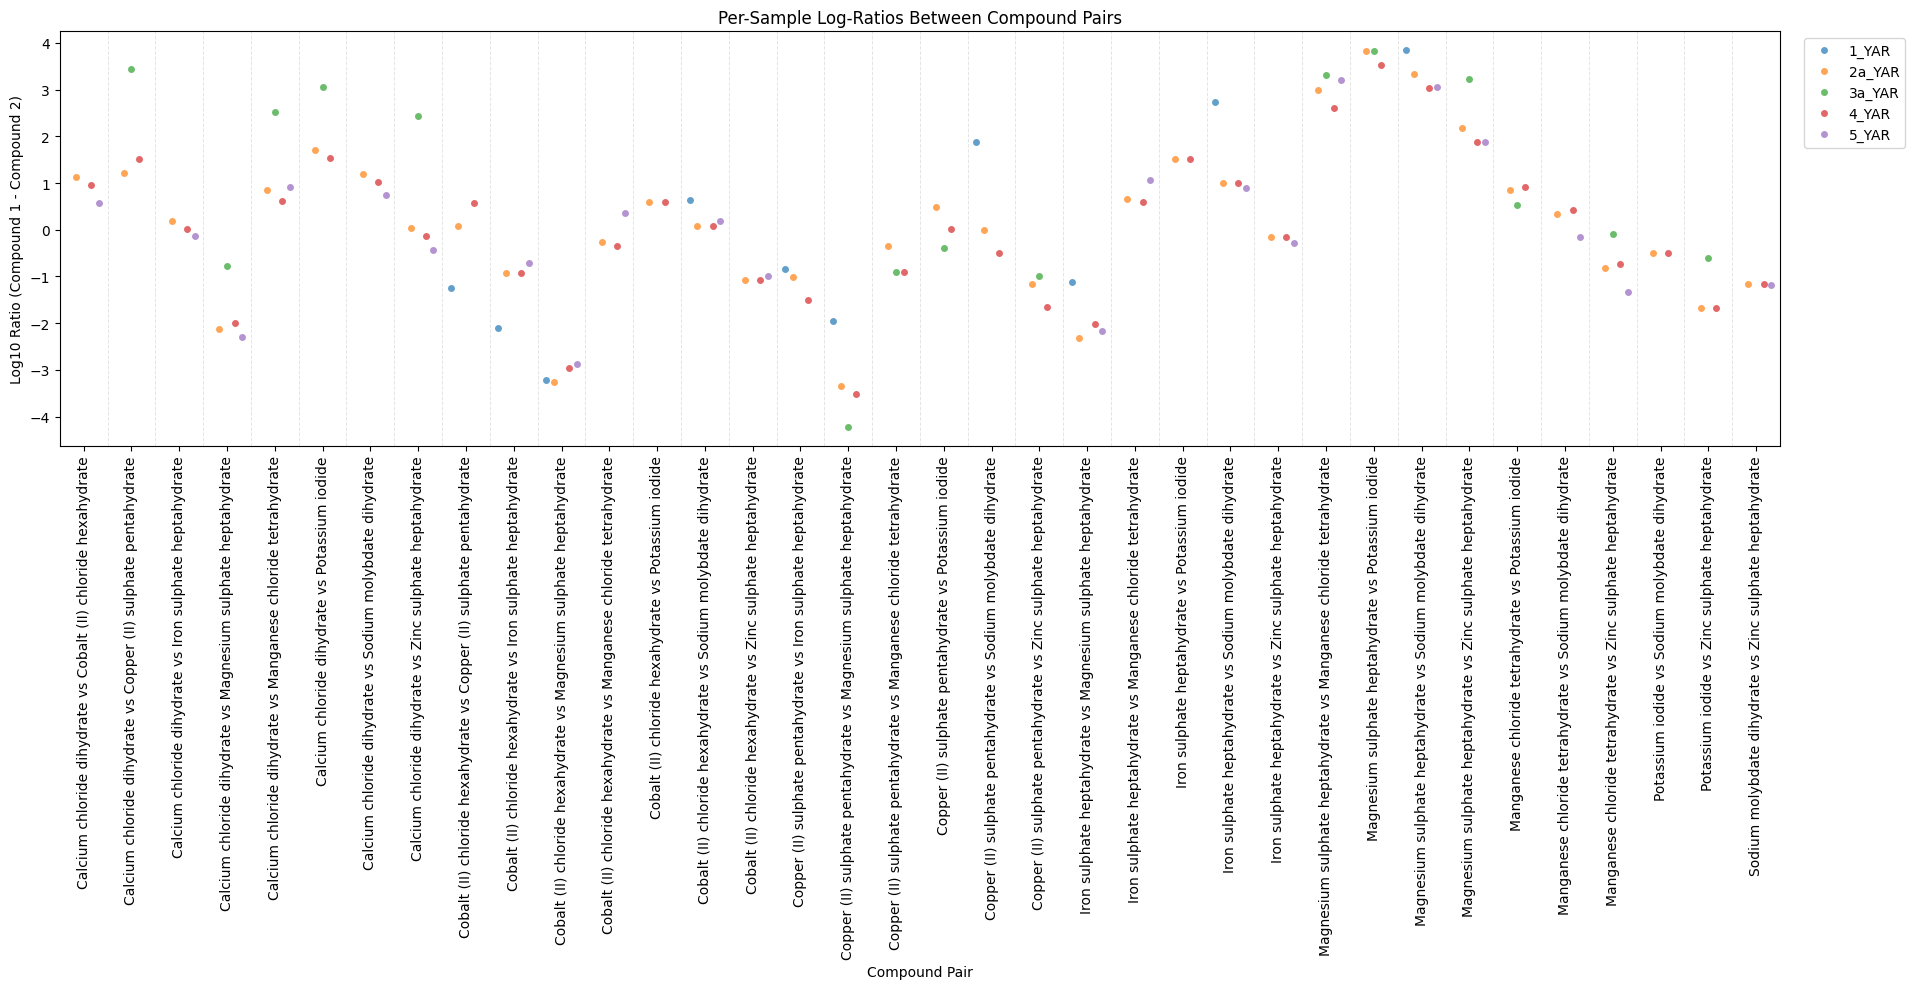

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

sns.stripplot(
    data=ratio_long,
    x='Pair',
    y='Log_Ratio',
    hue='Sample',
    jitter=True,
    dodge=True,
    alpha=0.7
)


plt.xticks(rotation=90)
plt.ylabel("Log10 Ratio (Compound 1 - Compound 2)")
plt.xlabel("Compound Pair")
plt.title("Per-Sample Log-Ratios Between Compound Pairs")
plt.tight_layout()
n_categories = len(plt.gca().get_xticks())
for x in np.arange(0.5, n_categories, 1):
    plt.axvline(x=x, color='lightgray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()


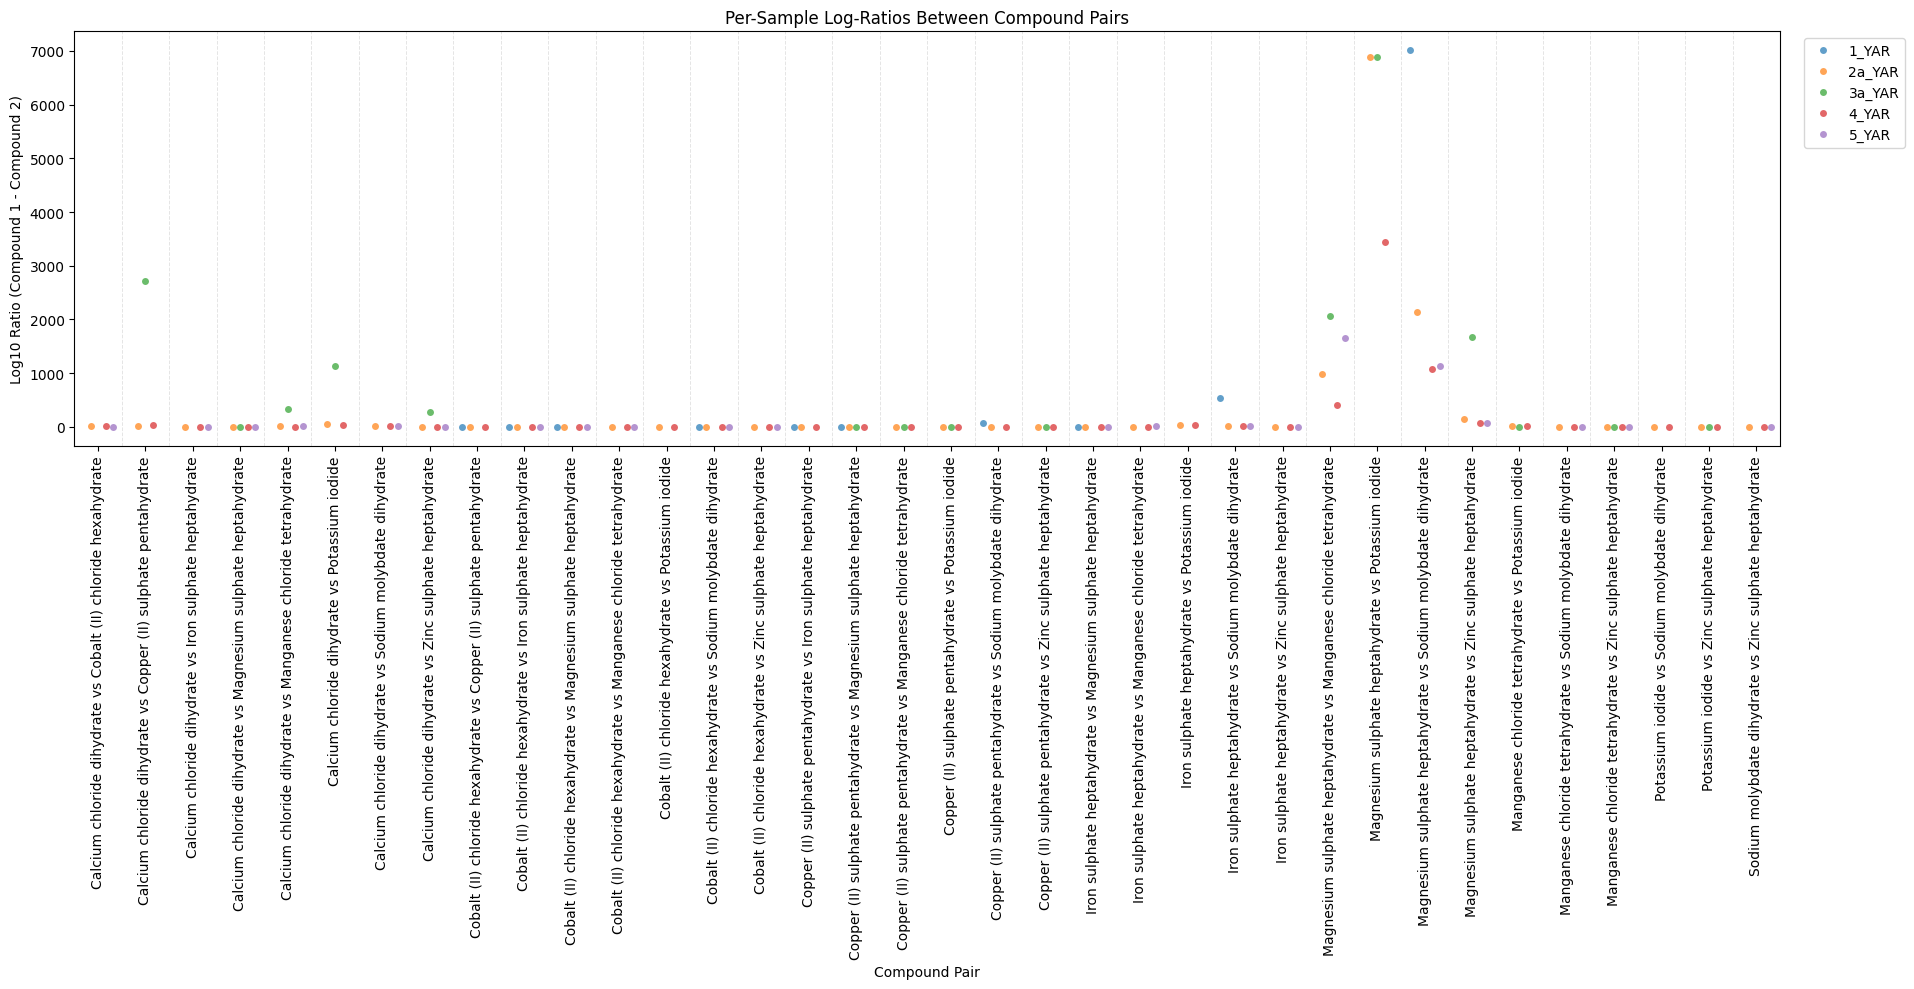

In [72]:
ratio_long = pd.melt(
    ratio_df_reduced_linear,
    id_vars=['Compound_1', 'Compound_2'],
    var_name='Sample',
    value_name='Log_Ratio'
)

# Combine compound pair into a single string for plotting
ratio_long['Pair'] = ratio_long['Compound_1'] + " vs " + ratio_long['Compound_2']

plt.figure(figsize=(18, 10))

sns.stripplot(
    data=ratio_long,
    x='Pair',
    y='Log_Ratio',
    hue='Sample',
    jitter=True,
    dodge=True,
    alpha=0.7
)


plt.xticks(rotation=90)
plt.ylabel("Log10 Ratio (Compound 1 - Compound 2)")
plt.xlabel("Compound Pair")
plt.title("Per-Sample Log-Ratios Between Compound Pairs")
plt.tight_layout()
n_categories = len(plt.gca().get_xticks())
for x in np.arange(0.5, n_categories, 1):
    plt.axvline(x=x, color='lightgray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()